# NYS Donate Life

### Reseach Question

How can New York State identify and prioritize communities at risk of low organ donor registration to support equity-centered outreach and resource allocation?

#### Dataset
https://health.data.ny.gov/Health/New-York-State-Donate-Life-Registry-Enrollment-by-/gvq6-s8vf/about_data

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
# !pip install pandas

In [51]:
# !pip install seaborn

In [52]:
donate_df = pd.read_csv('New_York_State_Donate_Life_Registry_Enrollment_by_Zip_Code_20260228.csv', low_memory=False)
donate_df.head()

,Zip Code,Year,Month,Registry Enrollments
0,14850,2008,9,246
1,11215,2008,9,200
2,10025,2008,9,193
3,11238,2008,9,160
4,11201,2008,9,154


In [53]:
donate_df.tail()

,Zip Code,Year,Month,Registry Enrollments
159706,10128,2026,1,11
159707,10025,2026,1,11
159708,10016,2026,1,11
159709,10019,2026,1,10
159710,11216,2026,1,10


In [54]:
donate_df.describe()

,Zip Code,Year,Month
count,159711.000000,159711.000000,159711.000000
mean,12331.583642,2016.707190,6.562666
std,1442.246555,4.995214,3.416615
min,7310.000000,2008.000000,1.000000
25%,11218.000000,2012.000000,4.000000
50%,12053.000000,2017.000000,7.000000
75%,13619.000000,2021.000000,10.000000
max,14905.000000,2026.000000,12.000000


In [55]:
donate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159711 entries, 0 to 159710
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Zip Code              159711 non-null  int64 
 1   Year                  159711 non-null  int64 
 2   Month                 159711 non-null  int64 
 3   Registry Enrollments  159711 non-null  object
dtypes: int64(3), object(1)
memory usage: 4.9+ MB


- 159,711 entries
- `Year` 2008-2026 
- `Month` 1-12



In [56]:
donate_df.sort_values('Registry Enrollments', ascending=True) 

,Zip Code,Year,Month,Registry Enrollments
4946,10021,2009,5,"1,104"
129747,14487,2022,7,10
129746,14733,2022,7,10
129745,10589,2022,7,10
129744,13044,2022,7,10
...,...,...,...,...
72470,14450,2016,9,99
72471,14094,2016,9,99
46092,10456,2013,4,99
26118,12601,2011,5,99


- aggregate all months of year by zipcode to see trends over years 2008-2026
- see which zip codes de/increased enrollment over time

In [57]:
# convert `Registry Enrollments` col into a float
donate_df["Registry Enrollments"] = pd.to_numeric(donate_df["Registry Enrollments"], downcast="float")

ValueError: Unable to parse string "1,104" at position 4946

In [58]:
# show error with comma preventing dtype conversion
donate_df.loc[4946]

Zip Code                10021
Year                     2009
Month                       5
Registry Enrollments    1,104
Name: 4946, dtype: object

In [59]:
# replace all commas in `Registry Enrollments` col with nothing
donate_df['Registry Enrollments'] = donate_df['Registry Enrollments'].str.replace(',', '')

In [60]:
# show row again to verify comma is removed
donate_df.loc[4946]

Zip Code                10021
Year                     2009
Month                       5
Registry Enrollments     1104
Name: 4946, dtype: object

In [61]:
# attempt 2: convert `Registry Enrollments` col into a float
donate_df["Registry Enrollments"] = pd.to_numeric(donate_df["Registry Enrollments"], downcast="float")

In [62]:
# verify dtypes
donate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159711 entries, 0 to 159710
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Zip Code              159711 non-null  int64  
 1   Year                  159711 non-null  int64  
 2   Month                 159711 non-null  int64  
 3   Registry Enrollments  159711 non-null  float32
dtypes: float32(1), int64(3)
memory usage: 4.3 MB


In [63]:
# show sorted list again
donate_df.sort_values('Registry Enrollments', ascending=True) 

,Zip Code,Year,Month,Registry Enrollments
159710,11216,2026,1,10.0
140837,11422,2023,11,10.0
140836,13795,2023,11,10.0
140835,10006,2023,11,10.0
140834,12033,2023,11,10.0
...,...,...,...,...
4949,10023,2009,5,740.0
61310,11215,2015,5,780.0
4948,10024,2009,5,845.0
4947,10025,2009,5,984.0


@ first glance: (1) zip codes with high enrolment per month & year are in Manhattan 10021 UES, 10025 UWS/Morningside Heights, 10024 UWS, 10023 UWS; (2) only 1 in Brooklyn 11215. 
- What would aggregate data show?
  

In [64]:
# aggregate data by month & year

yearly_df = (
    donate_df
    .groupby(["Zip Code", "Year"], as_index=False)
    .agg({
        "Registry Enrollments": "sum"
    })
)

In [65]:
yearly_df

,Zip Code,Year,Registry Enrollments
0,7310,2016,10.0
1,10001,2008,167.0
2,10001,2009,709.0
3,10001,2010,759.0
4,10001,2011,788.0
...,...,...,...
18225,14905,2021,276.0
18226,14905,2022,178.0
18227,14905,2023,243.0
18228,14905,2024,281.0


In [66]:
yearly_df.sort_values('Year', ascending=True )

,Zip Code,Year,Registry Enrollments
13318,13634,2008,10.0
15551,14225,2008,161.0
2292,10601,2008,73.0
9665,12549,2008,23.0
15569,14226,2008,181.0
...,...,...,...
4277,11238,2026,14.0
3878,11215,2026,13.0
760,10128,2026,11.0
3988,11221,2026,16.0


In [67]:
yearly_df.sort_values('Zip Code', ascending=True )

,Zip Code,Year,Registry Enrollments
0,7310,2016,10.0
18,10001,2025,902.0
17,10001,2024,961.0
16,10001,2023,901.0
15,10001,2022,817.0
...,...,...,...
18213,14905,2009,435.0
18212,14905,2008,57.0
18228,14905,2024,281.0
18219,14905,2015,227.0


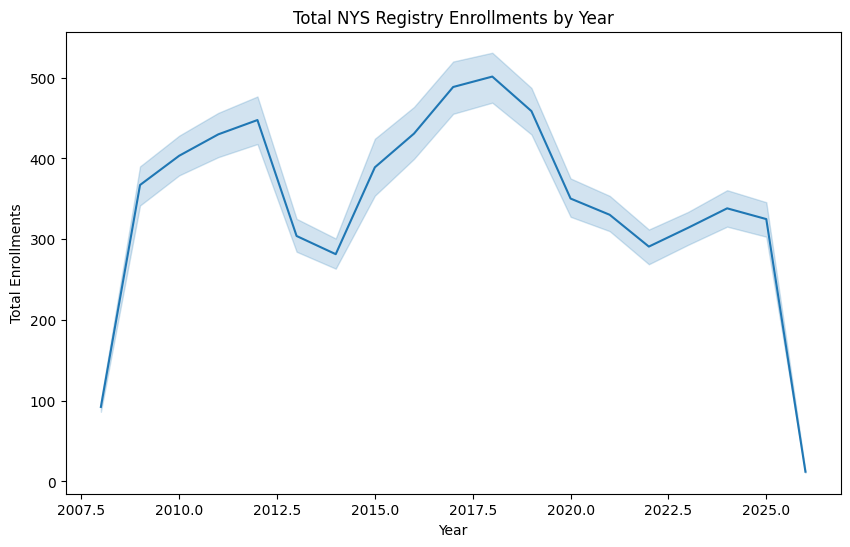

In [68]:
# visualize enrollment from 2008 to 2026 independent of zip codes

plt.figure(figsize=(10,6))

sns.lineplot(
    data=yearly_df,
    x="Year",
    y="Registry Enrollments"
)

plt.title("Total NYS Registry Enrollments by Year")
plt.xlabel("Year")
plt.ylabel("Total Enrollments")
plt.show()

In [69]:
# see data in table format

yearly_totals = (
    yearly_df
    .groupby("Year", as_index=False)
    .agg({"Registry Enrollments": "sum"})
    .sort_values("Year")
)
yearly_totals

,Year,Registry Enrollments
0,2008,62797.0
1,2009,453728.0
2,2010,449287.0
3,2011,486162.0
4,2012,499021.0
5,2013,280256.0
6,2014,230767.0
7,2015,324444.0
8,2016,403212.0
9,2017,576909.0


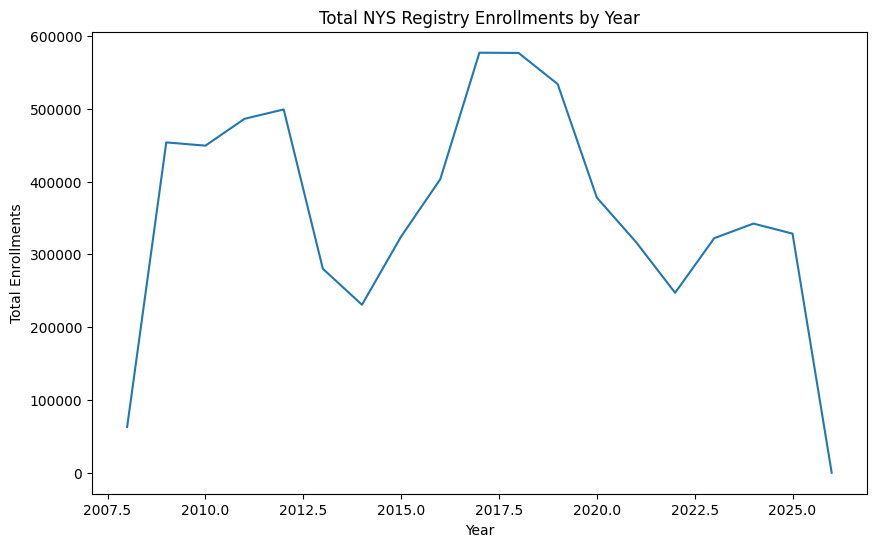

In [70]:
# double check visuzliation using `yearly_totals_df`

plt.figure(figsize=(10,6))

sns.lineplot(
    data=yearly_totals,
    x="Year",
    y="Registry Enrollments"
)

plt.title("Total NYS Registry Enrollments by Year")
plt.xlabel("Year")
plt.ylabel("Total Enrollments")
plt.show()